# MLP feedforward bagging ensemble

En esta notebook se hace bagging! yupi!

In [1]:
from pathlib import Path
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.utils.class_weight import compute_class_weight

from scripts import style
style.mpl_apply()

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
SEED = 246
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

# Load the data

In [2]:
DATA_PATH = Path("09 features/redes_local/datos/processed/df.csv")

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (200, 57)


,mean_R,mean_G,mean_B,std_R,std_G,std_B,min_R,min_G,min_B,max_R,...,pct_bright_block_2_2,H_shannon,center_mean_ratio,center_bright_ratio,lum_centroid_x,lum_centroid_y,filename,painter,genre,label
0,102.20103,105.277170,106.873116,32.077003,33.305286,33.510914,0.0,0.0,0.0,186.0,...,0.195138,-1419.565426,1.198618,1.749636,0.486834,-0.154286,Alfred_Sisley_1.jpg,Alfred_Sisley,Impresionismo,4
1,123.62030,136.959850,149.195050,46.771084,43.979904,49.263435,0.0,0.0,0.0,255.0,...,0.098290,-1419.565426,1.061136,0.937835,0.502996,-0.188640,Alfred_Sisley_10.jpg,Alfred_Sisley,Impresionismo,4
2,118.90262,116.895996,108.091415,48.649280,52.237015,61.140570,0.0,0.0,0.0,255.0,...,0.117654,-1419.489874,0.852622,1.311007,0.504956,-0.304950,Alfred_Sisley_11.jpg,Alfred_Sisley,Impresionismo,4
3,133.78065,140.773590,146.314380,36.072636,36.483162,50.136950,4.0,4.0,0.0,255.0,...,0.018207,-1419.565426,1.091522,1.702214,0.500399,-0.215292,Alfred_Sisley_12.jpg,Alfred_Sisley,Impresionismo,4
4,107.30281,108.520706,92.723560,32.748276,32.094944,37.935650,0.0,0.0,0.0,229.0,...,0.020639,-1419.565426,1.132043,2.128325,0.506062,-0.137083,Alfred_Sisley_13.jpg,Alfred_Sisley,Impresionismo,4


In [3]:
# Encode painters
painter_names = sorted(df["painter"].unique())
painter_to_idx = {name: i for i, name in enumerate(painter_names)}
idx_to_painter = {i: name for name, i in painter_to_idx.items()}

df["painter_idx"] = df["painter"].map(painter_to_idx)

NUM_PAINTERS = len(painter_names)

# Labels (movement / genre index)
# Assume df["label"] is already integer-coded per genre
NUM_LABELS = df["label"].nunique()

# Derive genre names per label (sorted by label index)
label_to_genre = (
    df.drop_duplicates("label")
      .sort_values("label")
      .set_index("label")["genre"]
      .to_dict()
)
class_names = [label_to_genre[i] for i in range(NUM_LABELS)]

print("Painters:", painter_names)
print("NUM_PAINTERS:", NUM_PAINTERS)
print("NUM_LABELS:", NUM_LABELS)
print("Labels → genres:", label_to_genre)


Painters: ['Alfred_Sisley', 'Camille_Pissarro', 'Caravaggio', 'Claude_Monet', 'Jackson_Pollock', 'Joan_Miro', 'Pablo_Picasso', 'Rembrandt', 'Rene_Magritte', 'Salvador_Dali', 'Vincent_van_Gogh']
NUM_PAINTERS: 11
NUM_LABELS: 5
Labels → genres: {0: 'Surrealismo', 1: 'Cubismo', 2: 'Expresionismo abstracto', 3: 'Barroco', 4: 'Impresionismo'}


In [4]:
meta_cols = ["filename", "painter", "genre", "label", "painter_idx"]

feature_cols = [c for c in df.columns if c not in meta_cols]

X = df[feature_cols].to_numpy(dtype=np.float32)
y_painter = df["painter_idx"].to_numpy(dtype=np.int64)
y_label   = df["label"].to_numpy(dtype=np.int64)

print("X shape:", X.shape)
print("y_painter shape:", y_painter.shape)
print("y_label shape:", y_label.shape)
print("Painter counts:", np.bincount(y_painter))
print("Label counts:",   np.bincount(y_label))


X shape: (200, 53)
y_painter shape: (200,)
y_label shape: (200,)
Painter counts: [20 10 10 30 15 20 30 20 10 20 15]
Label counts: [50 30 15 30 75]


# Train Set and Validation Set

In [5]:
# === Cell 4: train / validation split (no test split here) ===

X_train, X_val, y_p_train, y_p_val, y_l_train, y_l_val = train_test_split(
    X,
    y_painter,
    y_label,
    test_size=0.1,           # e.g. 80% train / 20% val
    stratify=y_painter,      # stratify by painter (since painter is first task)
    random_state=SEED,
)

print("Train X:", X_train.shape)
print("Val   X:", X_val.shape)


Train X: (180, 53)
Val   X: (20, 53)


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)


In [7]:
BATCH_SIZE = 32

X_train_t = torch.from_numpy(X_train_scaled).float()
y_p_train_t = torch.from_numpy(y_p_train).long()
y_l_train_t = torch.from_numpy(y_l_train).long()

X_val_t = torch.from_numpy(X_val_scaled).float()
y_p_val_t = torch.from_numpy(y_p_val).long()
y_l_val_t = torch.from_numpy(y_l_val).long()

train_ds = TensorDataset(X_train_t, y_p_train_t, y_l_train_t)
val_ds   = TensorDataset(X_val_t,   y_p_val_t,   y_l_val_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

len(train_loader), len(val_loader)


(6, 1)

In [8]:
# === Cell 7: class weights for imbalance ===

# Painter weights
painter_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_PAINTERS),
    y=y_p_train,
)

# Label weights (genre / movement)
label_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_LABELS),
    y=y_l_train,
)

print("Painter class weights:", painter_class_weights)
print("Label   class weights:", label_class_weights)

painter_class_weights_t = torch.tensor(painter_class_weights, dtype=torch.float32, device=device)
label_class_weights_t   = torch.tensor(label_class_weights,   dtype=torch.float32, device=device)


Painter class weights: [0.90909091 1.81818182 1.81818182 0.60606061 1.25874126 0.90909091
 0.60606061 0.90909091 1.81818182 0.90909091 1.16883117]
Label   class weights: [0.8        1.33333333 2.76923077 1.33333333 0.52941176]


# Architectures

## MLP

In [9]:
# === Cell 8: multi-task MLP definition ===

class MultiTaskMLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dims=(128, 64),
        num_painters: int = NUM_PAINTERS,
        num_labels: int = NUM_LABELS,
        dropout_p: float = 0.3,
    ):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_p))
            prev_dim = h

        self.shared = nn.Sequential(*layers)
        self.painter_head = nn.Linear(prev_dim, num_painters)
        self.label_head   = nn.Linear(prev_dim, num_labels)

    def forward(self, x: torch.Tensor):
        z = self.shared(x)
        painter_logits = self.painter_head(z)
        label_logits   = self.label_head(z)
        return painter_logits, label_logits


## MLP Slim More dropout

In [10]:
import torch
import torch.nn as nn

class MultiTaskMLP_Slim(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_painters: int,
        num_labels: int,
        bottleneck: int = 16,
        hidden_first: int = 32,
        dropout_p: float = 0.5,
    ):
        super().__init__()

        self.trunk = nn.Sequential(
            nn.Linear(input_dim, hidden_first),
            nn.BatchNorm1d(hidden_first),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(hidden_first, bottleneck),
            nn.Tanh(),
            nn.Dropout(dropout_p),
        )

        self.painter_head = nn.Linear(bottleneck, num_painters)
        self.label_head   = nn.Linear(bottleneck, num_labels)

    def forward(self, x: torch.Tensor):
        h = self.trunk(x)
        painter_logits = self.painter_head(h)
        label_logits   = self.label_head(h)
        return painter_logits, label_logits

## RBF

In [11]:
from sklearn.cluster import KMeans

N_RBF = 32    # number of RBF centers; keep small (10–40)
kmeans = KMeans(n_clusters=N_RBF, random_state=SEED)
kmeans.fit(X_train_scaled)   # shape (n_train, d)

centers = torch.from_numpy(kmeans.cluster_centers_).float().to(device)


c:\Users\herie\miniconda3\envs\dl\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [12]:
class RBFLayer(nn.Module):
    def __init__(self, centers: torch.Tensor, gamma: float = 1.0):
        """
        centers: (K, D) tensor (fixed)
        gamma: 1/(2*sigma^2); controls width of RBFs
        """
        super().__init__()
        self.centers = nn.Parameter(centers, requires_grad=False)
        self.gamma = nn.Parameter(torch.tensor(gamma, dtype=torch.float32), requires_grad=False)

    def forward(self, x: torch.Tensor):
        # x: (B, D), centers: (K, D)
        # Compute squared distances: (B, K)
        # ||x - c||^2 = (x^2).sum + (c^2).sum - 2 x·c
        x2 = (x ** 2).sum(dim=1, keepdim=True)              # (B, 1)
        c2 = (self.centers ** 2).sum(dim=1).unsqueeze(0)    # (1, K)
        xc = x @ self.centers.t()                           # (B, K)
        dist2 = x2 + c2 - 2 * xc
        # RBF activations
        phi = torch.exp(-self.gamma * dist2)
        return phi


In [13]:
class MultiTaskMLP_RBF(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_painters: int,
        num_labels: int,
        centers: torch.Tensor,
        hidden_first: int = 32,
        dropout_p: float = 0.4,
        gamma: float = 1.0,
    ):
        super().__init__()

        # Linear pre-transform to "RBF space"
        self.pre = nn.Sequential(
            nn.Linear(input_dim, hidden_first),
            nn.ReLU(),
            nn.Dropout(dropout_p),
        )

        self.rbf = RBFLayer(centers, gamma=gamma)  # output dim = N_RBF

        rbf_dim = centers.shape[0]

        self.painter_head = nn.Sequential(
            nn.Linear(rbf_dim, num_painters),
        )
        self.label_head   = nn.Sequential(
            nn.Linear(rbf_dim, num_labels),
        )

    def forward(self, x: torch.Tensor):
        h = self.pre(x)
        phi = self.rbf(h)
        painter_logits = self.painter_head(phi)
        label_logits   = self.label_head(phi)
        return painter_logits, label_logits


In [14]:
import torch
import torch.nn as nn

class RBFLayerLearnable(nn.Module):
    def __init__(self, in_dim: int, num_centers: int, init_gamma: float = 1.0):
        """
        in_dim:      dimensionality of the input to this RBF layer (e.g. hidden_first)
        num_centers: number of RBF units K
        init_gamma:  initial gamma; effective RBF is exp(-gamma * ||x - c||^2)
        """
        super().__init__()
        self.in_dim = in_dim
        self.num_centers = num_centers

        # Centers are learnable parameters: (K, D)
        self.centers = nn.Parameter(
            0.1 * torch.randn(num_centers, in_dim)  # small random init
        )

        # Learnable log-gamma so that gamma stays > 0
        self.log_gamma = nn.Parameter(
            torch.log(torch.tensor(init_gamma, dtype=torch.float32))
        )

    def forward(self, x: torch.Tensor):
        """
        x: (B, D) where D = in_dim
        returns: (B, K) RBF activations
        """
        # ensure gamma > 0
        gamma = torch.exp(self.log_gamma)

        # x^2: (B, 1)
        x2 = (x ** 2).sum(dim=1, keepdim=True)
        # c^2: (1, K)
        c2 = (self.centers ** 2).sum(dim=1).unsqueeze(0)
        # x·c: (B, K)
        xc = x @ self.centers.t()

        # squared distance: (B, K)
        dist2 = x2 + c2 - 2 * xc

        # RBF features: (B, K)
        phi = torch.exp(-gamma * dist2)
        return phi


## RBF Learnable

In [15]:
class MultiTaskMLP_RBF_Learnable(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_painters: int,
        num_labels: int,
        hidden_first: int = 32,
        n_rbf: int = 20,
        dropout_p: float = 0.4,
        init_gamma: float = 1.0,
    ):
        super().__init__()

        # Linear + ReLU pre-transform: R^d -> R^{hidden_first}
        self.pre = nn.Sequential(
            nn.Linear(input_dim, hidden_first),
            nn.ReLU(),
            nn.Dropout(dropout_p),
        )

        # RBF layer in this hidden space: centers ∈ R^{n_rbf × hidden_first}
        self.rbf = RBFLayerLearnable(
            in_dim=hidden_first,
            num_centers=n_rbf,
            init_gamma=init_gamma,
        )

        self.dropout = nn.Dropout(dropout_p)

        # Heads see K-dimensional RBF feature vector
        self.painter_head = nn.Linear(n_rbf, num_painters)
        self.label_head   = nn.Linear(n_rbf, num_labels)

    def forward(self, x: torch.Tensor):
        # x: (B, input_dim)
        h = self.pre(x)          # (B, hidden_first)
        phi = self.rbf(h)        # (B, n_rbf)
        phi = self.dropout(phi)  # optional extra regularization

        painter_logits = self.painter_head(phi)  # (B, num_painters)
        label_logits   = self.label_head(phi)    # (B, num_labels)
        return painter_logits, label_logits


# Training

In [16]:
EPOCHS = 1000
LR = 1e-3
WEIGHT_DECAY = 1e-4

painter_criterion = nn.CrossEntropyLoss(weight=painter_class_weights_t)
label_criterion   = nn.CrossEntropyLoss(weight=label_class_weights_t)

LAMBDA_P = 1.0   # weight for painter loss
LAMBDA_L = 1.0   # weight for label loss

In [17]:
K = 5  # number of models in bagging
MAX_EPOCHS = 1000
PATIENCE = 250

In [ ]:
input_dim = X_train_t.shape[1]

In [19]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    painter_criterion,
    label_criterion,
    device,
    lambda_p: float = 1.0,
    lambda_l: float = 1.0,
):
    model.train()
    total = 0
    sum_loss = 0.0
    correct_painter = 0
    correct_label = 0

    for X_batch, y_p_batch, y_l_batch in loader:
        X_batch = X_batch.to(device)
        y_p_batch = y_p_batch.to(device)
        y_l_batch = y_l_batch.to(device)

        optimizer.zero_grad()
        painter_logits, label_logits = model(X_batch)

        painter_loss = painter_criterion(painter_logits, y_p_batch)
        label_loss   = label_criterion(label_logits,   y_l_batch)
        loss = lambda_p * painter_loss + lambda_l * label_loss

        loss.backward()
        optimizer.step()

        batch_size = X_batch.size(0)
        sum_loss += loss.item() * batch_size
        total += batch_size

        painter_pred = painter_logits.argmax(dim=1)
        label_pred   = label_logits.argmax(dim=1)

        correct_painter += (painter_pred == y_p_batch).sum().item()
        correct_label   += (label_pred   == y_l_batch).sum().item()

    epoch_loss = sum_loss / total
    painter_acc = correct_painter / total
    label_acc   = correct_label   / total
    return epoch_loss, painter_acc, label_acc


@torch.no_grad()
def evaluate(
    model,
    loader,
    painter_criterion,
    label_criterion,
    device,
    lambda_p: float = 1.0,
    lambda_l: float = 1.0,
):
    model.eval()
    total = 0
    sum_loss = 0.0
    correct_painter = 0
    correct_label = 0

    for X_batch, y_p_batch, y_l_batch in loader:
        X_batch = X_batch.to(device)
        y_p_batch = y_p_batch.to(device)
        y_l_batch = y_l_batch.to(device)

        painter_logits, label_logits = model(X_batch)

        painter_loss = painter_criterion(painter_logits, y_p_batch)
        label_loss   = label_criterion(label_logits,   y_l_batch)
        loss = lambda_p * painter_loss + lambda_l * label_loss

        batch_size = X_batch.size(0)
        sum_loss += loss.item() * batch_size
        total += batch_size

        painter_pred = painter_logits.argmax(dim=1)
        label_pred   = label_logits.argmax(dim=1)

        correct_painter += (painter_pred == y_p_batch).sum().item()
        correct_label   += (label_pred   == y_l_batch).sum().item()

    epoch_loss = sum_loss / total
    painter_acc = correct_painter / total
    label_acc   = correct_label   / total
    return epoch_loss, painter_acc, label_acc

In [20]:
@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()
    all_y_p = []
    all_y_l = []
    all_l_logits = []

    for X_batch, y_p_batch, y_l_batch in loader:
        X_batch = X_batch.to(device)
        l_logits = model(X_batch)[1]

        all_y_p.append(y_p_batch)  # only for completeness
        all_y_l.append(y_l_batch)
        all_l_logits.append(l_logits.cpu())

    y_l_true = torch.cat(all_y_l).numpy()
    l_logits = torch.cat(all_l_logits)
    y_l_pred = l_logits.argmax(dim=1).numpy()
    return y_l_true, y_l_pred


In [21]:
from sklearn.utils.class_weight import compute_class_weight

def make_criterions(criterion_mode, y_p_train, y_l_train, device):
    """
    Returns painter_criterion, label_criterion given mode and train labels.
    """
    if criterion_mode == "both_weighted":
        painter_w = compute_class_weight(
            class_weight="balanced",
            classes=np.arange(NUM_PAINTERS),
            y=y_p_train,
        )
        label_w = compute_class_weight(
            class_weight="balanced",
            classes=np.arange(NUM_LABELS),
            y=y_l_train,
        )
        painter_w_t = torch.tensor(painter_w, dtype=torch.float32, device=device)
        label_w_t   = torch.tensor(label_w,   dtype=torch.float32, device=device)
        painter_criterion = nn.CrossEntropyLoss(weight=painter_w_t)
        label_criterion   = nn.CrossEntropyLoss(weight=label_w_t)

    elif criterion_mode == "label_only_weighted":
        label_w = compute_class_weight(
            class_weight="balanced",
            classes=np.arange(NUM_LABELS),
            y=y_l_train,
        )
        label_w_t = torch.tensor(label_w, dtype=torch.float32, device=device)
        painter_criterion = nn.CrossEntropyLoss()                 # unweighted
        label_criterion   = nn.CrossEntropyLoss(weight=label_w_t)

    elif criterion_mode == "unweighted":
        painter_criterion = nn.CrossEntropyLoss()
        label_criterion   = nn.CrossEntropyLoss()

    else:
        raise ValueError(f"Unknown criterion_mode: {criterion_mode}")

    return painter_criterion, label_criterion


# Cross Validation

In [27]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from torch.utils.data import TensorDataset, DataLoader
import copy

def cross_val_score_config(
    config,
    X_all,
    y_p_all,
    y_l_all,
    n_splits: int = 5,
    max_epochs: int = 40,
    patience: int = 8,
    base_seed: int = 42,
    batch_size: int = 32,
):
    """
    config: dict with keys:
        'hidden_first', 'bottleneck', 'dropout_p',
        'lr', 'weight_decay',
        'lambda_p', 'lambda_l',
        'criterion_mode'
    returns: mean_f1_macro, std_f1_macro
    """

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=base_seed,
    )

    fold_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_all, y_p_all)):
        print(f"\n--- Fold {fold_idx+1}/{n_splits} ---")

        X_tr = X_all[train_idx]
        y_p_tr = y_p_all[train_idx]
        y_l_tr = y_l_all[train_idx]

        X_va = X_all[val_idx]
        y_p_va = y_p_all[val_idx]
        y_l_va = y_l_all[val_idx]

        # scaling per-fold (fit on train only)
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_va_scaled = scaler.transform(X_va)

        # tensors
        X_tr_t = torch.from_numpy(X_tr_scaled).float()
        y_p_tr_t = torch.from_numpy(y_p_tr).long()
        y_l_tr_t = torch.from_numpy(y_l_tr).long()

        X_va_t = torch.from_numpy(X_va_scaled).float()
        y_p_va_t = torch.from_numpy(y_p_va).long()
        y_l_va_t = torch.from_numpy(y_l_va).long()

        train_ds = TensorDataset(X_tr_t, y_p_tr_t, y_l_tr_t)
        val_ds   = TensorDataset(X_va_t, y_p_va_t, y_l_va_t)

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

        # criterion (depends on fold's train labels)
        painter_criterion, label_criterion = make_criterions(
            config["criterion_mode"],
            y_p_tr,
            y_l_tr,
            device,
        )

        # model for this fold
        input_dim = X_all.shape[1]
        model = MultiTaskMLP_Slim(
            input_dim=input_dim,
            num_painters=NUM_PAINTERS,
            num_labels=NUM_LABELS,
            bottleneck=config["bottleneck"],
            hidden_first=config["hidden_first"],
            dropout_p=config["dropout_p"],
        ).to(device)

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config["lr"],
            weight_decay=config["weight_decay"],
        )

        # early stopping on label accuracy (or F1 if you want to compute it each epoch)
        best_state = None
        best_val_label_acc = -np.inf
        epochs_no_improve = 0

        for epoch in range(1, max_epochs + 1):
            train_loss, train_p_acc, train_l_acc = train_one_epoch(
                model,
                train_loader,
                optimizer,
                painter_criterion,
                label_criterion,
                device,
                lambda_p=config["lambda_p"],
                lambda_l=config["lambda_l"],
            )

            val_loss, val_p_acc, val_l_acc = evaluate(
                model,
                val_loader,
                painter_criterion,
                label_criterion,
                device,
                lambda_p=config["lambda_p"],
                lambda_l=config["lambda_l"],
            )

            print(
                f"  epoch {epoch:02d} | "
                f"train_loss={train_loss:.4f}, train_l_acc={train_l_acc:.3f} | "
                f"val_loss={val_loss:.4f}, val_l_acc={val_l_acc:.3f}"
            )

            if val_l_acc > best_val_label_acc + 1e-4:
                best_val_label_acc = val_l_acc
                best_state = copy.deepcopy(model.state_dict())
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print("  early stopping")
                    break

        if best_state is not None:
            model.load_state_dict(best_state)

        # final F1_macro on this fold (labels)
        y_l_true, y_l_pred = predict_loader(model, val_loader, device)
        f1_macro = f1_score(y_l_true, y_l_pred, average="macro")
        print(f"  fold {fold_idx+1} F1_macro (labels): {f1_macro:.3f}")

        fold_scores.append(f1_macro)

    mean_score = float(np.mean(fold_scores))
    std_score  = float(np.std(fold_scores))
    print(f"\n>>> Config {config} -> mean F1_macro={mean_score:.3f} ± {std_score:.3f}")
    return mean_score, std_score


In [23]:
import itertools

param_grid = {
    "hidden_first":  [32, 64],
    "bottleneck":    [16, 32],
    "dropout_p":     [0.3, 0.5],
    "lr":            [1e-3, 3e-4],
    "weight_decay":  [1e-4, 1e-5],
    "lambda_p":      [0.5, 1.0],
    "lambda_l":      [1.0, 1.5],
    "criterion_mode": ["both_weighted", "label_only_weighted"],
}

def iter_param_grid(grid_dict):
    keys = list(grid_dict.keys())
    values = [grid_dict[k] for k in keys]
    for combo in itertools.product(*values):
        yield {k: v for k, v in zip(keys, combo)}


In [25]:
# df has columns: feature_cols + ["painter", "genre", "label", "painter_idx"]
# if not, adapt from before
meta_cols = ["filename", "painter", "genre", "label", "painter_idx"]
feature_cols = [c for c in df.columns if c not in meta_cols]

X_all = df[feature_cols].to_numpy(dtype=np.float32)
y_p_all = df["painter_idx"].to_numpy(dtype=np.int64)
y_l_all = df["label"].to_numpy(dtype=np.int64)


In [28]:
best_config = None
best_score = -np.inf
results = []

for config in iter_param_grid(param_grid):
    print("\n============================================")
    print("Testing config:", config)
    mean_f1, std_f1 = cross_val_score_config(
        config,
        X_all=X_all,
        y_p_all=y_p_all,
        y_l_all=y_l_all,
        n_splits=5,
        max_epochs=40,
        patience=8,
        base_seed=42,
        batch_size=32,
    )
    results.append((config, mean_f1, std_f1))
    if mean_f1 > best_score:
        best_score = mean_f1
        best_config = config

print("\nBest config:", best_config)
print("Best mean F1_macro:", best_score)



Testing config: {'hidden_first': 32, 'bottleneck': 16, 'dropout_p': 0.3, 'lr': 0.001, 'weight_decay': 0.0001, 'lambda_p': 0.5, 'lambda_l': 1.0, 'criterion_mode': 'both_weighted'}

--- Fold 1/5 ---
  epoch 01 | train_loss=2.9143, train_l_acc=0.175 | val_loss=2.8529, val_l_acc=0.150
  epoch 02 | train_loss=2.8669, train_l_acc=0.169 | val_loss=2.8098, val_l_acc=0.300
  epoch 03 | train_loss=2.7524, train_l_acc=0.344 | val_loss=2.7620, val_l_acc=0.475
  epoch 04 | train_loss=2.7155, train_l_acc=0.331 | val_loss=2.7133, val_l_acc=0.550
  epoch 05 | train_loss=2.6878, train_l_acc=0.369 | val_loss=2.6688, val_l_acc=0.525
  epoch 06 | train_loss=2.6026, train_l_acc=0.412 | val_loss=2.6244, val_l_acc=0.525
  epoch 07 | train_loss=2.5886, train_l_acc=0.456 | val_loss=2.5828, val_l_acc=0.500
  epoch 08 | train_loss=2.5349, train_l_acc=0.525 | val_loss=2.5471, val_l_acc=0.475
  epoch 09 | train_loss=2.5567, train_l_acc=0.469 | val_loss=2.5139, val_l_acc=0.450
  epoch 10 | train_loss=2.4978, train

In [29]:
best_config

{'hidden_first': 32,
 'bottleneck': 32,
 'dropout_p': 0.3,
 'lr': 0.001,
 'weight_decay': 1e-05,
 'lambda_p': 1.0,
 'lambda_l': 1.0,
 'criterion_mode': 'label_only_weighted'}

In [41]:
# save the dictionary as a dict
import json
with open("best_mlp_slim_config.json", "w") as f:
    json.dump(best_config, f)

# Training

In [31]:
def make_slim_model():
    return MultiTaskMLP_Slim(
        input_dim=X_all.shape[1],
        num_painters=NUM_PAINTERS,
        num_labels=NUM_LABELS,
        bottleneck=best_config["bottleneck"],
        hidden_first=best_config["hidden_first"],
        dropout_p=best_config["dropout_p"],
    ).to(device)

In [32]:
import numpy as np
import random
import copy

def train_single_model_with_history(
    seed: int,
    max_epochs: int = 40,
    patience: int = 8,
    learning_rate: float = 1e-3,
    weight_decay: float = 1e-4,
    train_loader = train_loader,
    val_loader = val_loader,
    painter_criterion = painter_criterion,
    label_criterion = label_criterion,
    device = device,
    LAMBDA_L: float = 1.0,
    LAMBDA_P: float = 1.0,
):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = make_slim_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    history = {
        "train_loss": [],
        "train_painter_acc": [],
        "train_label_acc": [],
        "val_loss": [],
        "val_painter_acc": [],
        "val_label_acc": [],
    }

    best_state = None
    best_val_score = -np.inf
    epochs_no_improve = 0

    for epoch in range(1, max_epochs + 1):
        train_loss, train_p_acc, train_l_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            painter_criterion,
            label_criterion,
            device,
            lambda_p=LAMBDA_P,
            lambda_l=LAMBDA_L,
        )

        val_loss, val_p_acc, val_l_acc = evaluate(
            model,
            val_loader,
            painter_criterion,
            label_criterion,
            device,
            lambda_p=LAMBDA_P,
            lambda_l=LAMBDA_L,
        )

        history["train_loss"].append(train_loss)
        history["train_painter_acc"].append(train_p_acc)
        history["train_label_acc"].append(train_l_acc)
        history["val_loss"].append(val_loss)
        history["val_painter_acc"].append(val_p_acc)
        history["val_label_acc"].append(val_l_acc)

        # monitor label acc
        val_score = val_l_acc

        print(
            f"[seed {seed}] epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f}, train_l_acc={train_l_acc:.3f} | "
            f"val_loss={val_loss:.4f}, val_l_acc={val_l_acc:.3f}"
        )

        if val_score > best_val_score + 1e-4:
            best_val_score = val_score
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[seed {seed}] Early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_val_score


In [33]:
models = []
histories = []
scores = []

for k in range(K):
    seed_k = SEED + k  # or any base seed + k
    print(f"\n=== Training model {k+1}/{K} (seed={seed_k}) ===")
    model_k, hist_k, score_k = train_single_model_with_history(seed=seed_k,
                                                               max_epochs=MAX_EPOCHS,
                                                               patience=PATIENCE,
                                                               learning_rate=best_config["lr"],
                                                               weight_decay=best_config["weight_decay"],
                                                               train_loader=train_loader,
                                                               val_loader=val_loader,
                                                               painter_criterion=painter_criterion,
                                                               label_criterion=label_criterion,
                                                               device=device,
                                                               LAMBDA_L=best_config["lambda_l"],
                                                               LAMBDA_P=best_config["lambda_p"],
                                                               )
    models.append(model_k)
    histories.append(hist_k)
    scores.append(score_k)

print("Val label acc of each model:", scores)
print("Mean:", np.mean(scores), "Std:", np.std(scores))



=== Training model 1/5 (seed=246) ===
[seed 246] epoch 01 | train_loss=4.0740, train_l_acc=0.200 | val_loss=3.9810, val_l_acc=0.200
[seed 246] epoch 02 | train_loss=4.0031, train_l_acc=0.267 | val_loss=3.8840, val_l_acc=0.250
[seed 246] epoch 03 | train_loss=3.8390, train_l_acc=0.378 | val_loss=3.7861, val_l_acc=0.400
[seed 246] epoch 04 | train_loss=3.7525, train_l_acc=0.422 | val_loss=3.6959, val_l_acc=0.450
[seed 246] epoch 05 | train_loss=3.7147, train_l_acc=0.461 | val_loss=3.6085, val_l_acc=0.450
[seed 246] epoch 06 | train_loss=3.6289, train_l_acc=0.483 | val_loss=3.5256, val_l_acc=0.500
[seed 246] epoch 07 | train_loss=3.5857, train_l_acc=0.467 | val_loss=3.4507, val_l_acc=0.550
[seed 246] epoch 08 | train_loss=3.5184, train_l_acc=0.500 | val_loss=3.3736, val_l_acc=0.500
[seed 246] epoch 09 | train_loss=3.4108, train_l_acc=0.506 | val_loss=3.2997, val_l_acc=0.500
[seed 246] epoch 10 | train_loss=3.3699, train_l_acc=0.544 | val_loss=3.2321, val_l_acc=0.600
[seed 246] epoch 11 |

# Training Visualization

In [35]:
best_idx = int(np.argmax(scores))
best_history = histories[best_idx]
print("Best model index:", best_idx)

Best model index: 1


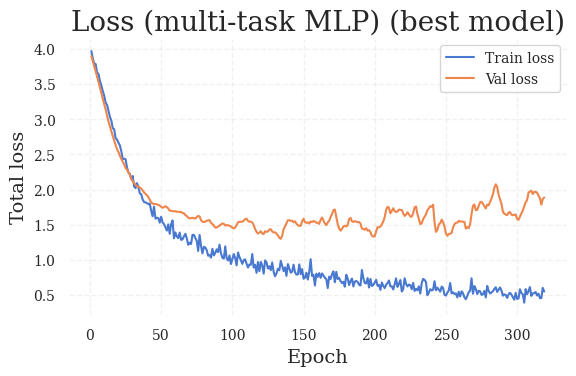

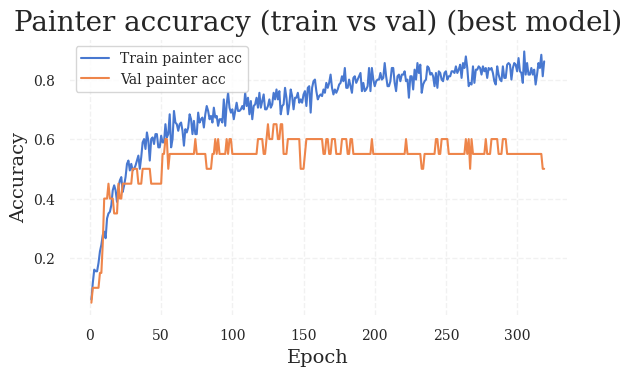

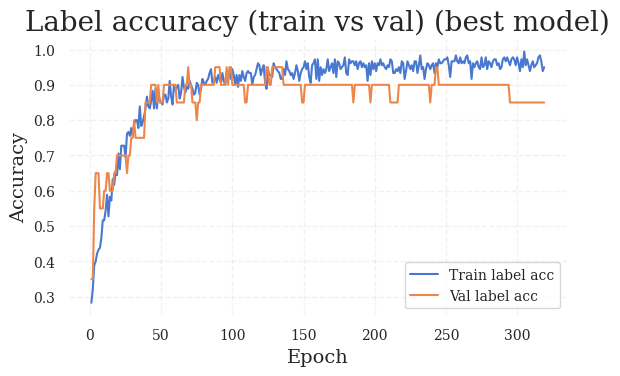

In [36]:
import matplotlib.pyplot as plt

def plot_history_one(history, title_suffix=""):
    epochs = range(1, len(history["train_loss"]) + 1)

    # Loss
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["val_loss"],   label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Total loss")
    plt.title(f"Loss (multi-task MLP){title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Painter accuracy
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_painter_acc"], label="Train painter acc")
    plt.plot(epochs, history["val_painter_acc"],   label="Val painter acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Painter accuracy (train vs val){title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Label accuracy
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_label_acc"], label="Train label acc")
    plt.plot(epochs, history["val_label_acc"],   label="Val label acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Label accuracy (train vs val){title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history_one(best_history, title_suffix=" (best model)")


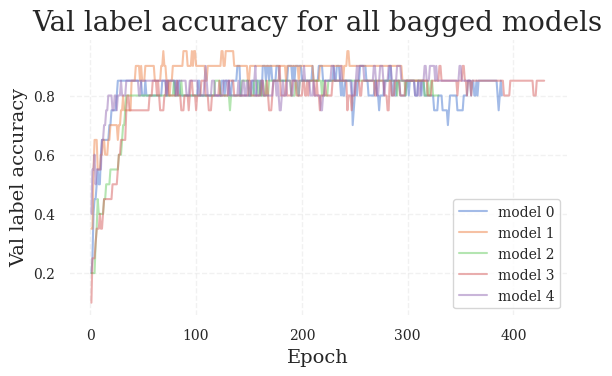

In [37]:
plt.figure(figsize=(6, 4))
for i, h in enumerate(histories):
    epochs = range(1, len(h["val_label_acc"]) + 1)
    plt.plot(epochs, h["val_label_acc"], alpha=0.5, label=f"model {i}" if i < 6 else None)
plt.xlabel("Epoch")
plt.ylabel("Val label accuracy")
plt.title("Val label accuracy for all bagged models")
plt.grid(True, alpha=0.3)
# If K small, show legend; otherwise remove
if K <= 6:
    plt.legend()
plt.tight_layout()
plt.show()


# Validation

In [1]:
import torch
import numpy as np

@torch.no_grad()
def ensemble_predict(models, X_t, device, return_logits=False):
    # accept numpy input
    if isinstance(X_t, np.ndarray):
        X_t = torch.from_numpy(X_t).float()

    X_t = X_t.to(device)

    p_logits_sum = None
    l_logits_sum = None
    multi_head = None  # detect on first forward

    for model in models:
        model.eval()
        out = model(X_t)

        # detect model type on first iteration
        if multi_head is None:
            multi_head = isinstance(out, (tuple, list)) and len(out) == 2

        if multi_head:
            p_logits, l_logits = out
            p_logits_sum = p_logits if p_logits_sum is None else p_logits_sum + p_logits
            l_logits_sum = l_logits if l_logits_sum is None else l_logits_sum + l_logits
        else:
            p_logits = out
            p_logits_sum = p_logits if p_logits_sum is None else p_logits_sum + p_logits

    # average
    p_logits_mean = p_logits_sum / len(models)
    y_p_pred = p_logits_mean.argmax(dim=1).cpu().numpy()

    if multi_head:
        l_logits_mean = l_logits_sum / len(models)
        y_l_pred = l_logits_mean.argmax(dim=1).cpu().numpy()

        if return_logits:
            return y_p_pred, y_l_pred, p_logits_mean, l_logits_mean
        return y_p_pred, y_l_pred

    if return_logits:
        return y_p_pred, p_logits_mean
    return y_p_pred


In [2]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

y_p_true = y_p_val_t.numpy()
y_l_true = y_l_val_t.numpy()

y_p_pred_ens, y_l_pred_ens = ensemble_predict(models, X_val_t, device)

print("Best single model val label acc:", np.max(scores))
print("Ensemble val label acc:", accuracy_score(y_l_true, y_l_pred_ens))
print("Ensemble val painter acc:", accuracy_score(y_p_true, y_p_pred_ens))


NameError: name 'y_p_val_t' is not defined

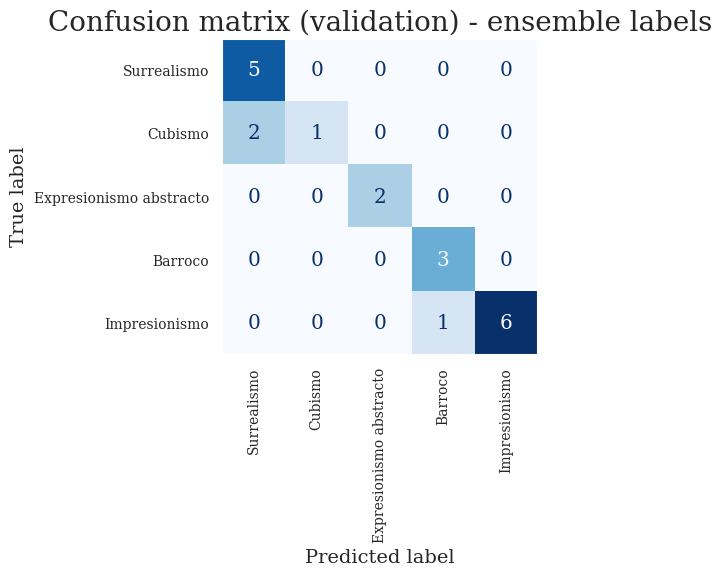

In [40]:
cm_label = confusion_matrix(y_l_true, y_l_pred_ens)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_label, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", xticks_rotation=90, ax=ax, colorbar=False)
plt.title("Confusion matrix (validation) - ensemble labels")
plt.tight_layout()
plt.grid(False)
plt.show()


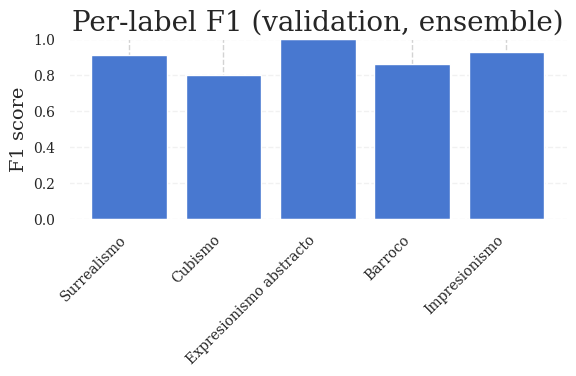

Surrealismo                   : F1 = 0.909
Cubismo                       : F1 = 0.800
Expresionismo abstracto       : F1 = 1.000
Barroco                       : F1 = 0.857
Impresionismo                 : F1 = 0.923


In [28]:
from sklearn.metrics import f1_score

f1_per_label = f1_score(
    y_l_true,
    y_l_pred_ens,
    average=None,
    labels=np.arange(NUM_LABELS),
)

plt.figure(figsize=(6, 4))
plt.bar(range(NUM_LABELS), f1_per_label)
plt.xticks(range(NUM_LABELS), class_names, rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.ylabel("F1 score")
plt.title("Per-label F1 (validation, ensemble)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

for name, f1_val in zip(class_names, f1_per_label):
    print(f"{name:30s}: F1 = {f1_val:.3f}")


# Test

In [ ]:
TEST_PATH = Path("09 features/redes_local/datos/processed/df_test.csv")

In [ ]:
# === Cell 18: load test df and predict (when df_test is available) ===

TEST_PATH = Path("09 features/redes_local/datos/processed/df_bb.csv")
df_test = pd.read_csv(TEST_PATH)

# Map painters with the *training* mapping
df_test["painter_idx"] = df_test["painter"].map(painter_to_idx)

# Optionally handle unknown painters
mask_unknown = df_test["painter_idx"].isna()
if mask_unknown.any():
    print("Warning: unknown painters in test:", df_test.loc[mask_unknown, "painter"].unique())
    df_test = df_test.loc[~mask_unknown].copy()

X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
X_test_scaled = scaler.transform(X_test)

X_test_t = torch.from_numpy(X_test_scaled).float().to(device)

with torch.no_grad():
    for model in models:
        p_logits_test, l_logits_test = model(X_test_t)
        y_p_pred_test = p_logits_test.argmax(dim=1).cpu().numpy()
        y_l_pred_test = l_logits_test.argmax(dim=1).cpu().numpy()

df_test["painter_pred"] = [idx_to_painter[i] for i in y_p_pred_test]
df_test["label_pred"]   = y_l_pred_test
df_test["genre_pred"]   = [class_names[i] for i in y_l_pred_test]

df_test.head()


,mean_R,mean_G,mean_B,std_R,std_G,std_B,min_R,min_G,min_B,max_R,...,lum_centroid_x,lum_centroid_y,filename,painter,genre,label,painter_idx,painter_pred,label_pred,genre_pred
0,113.894936,127.379160,103.34666,53.270428,70.752464,75.454780,0.0,2.0,0.0,255.0,...,0.553279,-0.467646,Alfred_Sisley_001.jpg,Alfred_Sisley,Impresionismo,4,0,Claude_Monet,4,Impresionismo
1,100.800140,91.574240,75.35645,76.134636,75.270805,72.747894,5.0,8.0,0.0,255.0,...,0.525715,-0.609516,Alfred_Sisley_002.jpg,Alfred_Sisley,Impresionismo,4,0,Caravaggio,3,Barroco
2,129.785230,116.044860,89.18722,47.168243,54.259525,42.555046,49.0,28.0,20.0,255.0,...,0.483567,-0.700687,Alfred_Sisley_003.jpg,Alfred_Sisley,Impresionismo,4,0,Caravaggio,3,Barroco
3,119.764275,126.478325,115.54521,55.139767,62.966022,80.313644,10.0,1.0,0.0,255.0,...,0.492189,-0.565718,Alfred_Sisley_004.jpg,Alfred_Sisley,Impresionismo,4,0,Claude_Monet,4,Impresionismo
4,143.549220,138.841380,130.06557,87.223040,88.330170,91.912506,3.0,7.0,0.0,255.0,...,0.511623,-0.144344,Alfred_Sisley_005.jpg,Alfred_Sisley,Impresionismo,4,0,Caravaggio,3,Barroco


: 

In [33]:
X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_painter_test = df_test["painter_idx"].to_numpy(dtype=np.int64)
y_label_test = df_test["label"].to_numpy(dtype=np.int64)

print("X_test shape:", X_test.shape)
print("y_painter_test shape:", y_painter_test.shape)
print("y_label_test shape:", y_label_test.shape)
print("Painter counts:", np.bincount(y_painter_test))
print("Label counts:",   np.bincount(y_label_test))

X_test shape: (750, 53)
y_painter_test shape: (750,)
y_label_test shape: (750,)
Painter counts: [70 60 60 80 65 70 80 70 60 70 65]
Label counts: [200  80  65 130 275]


In [34]:
X_test_scaled = scaler.transform(X_test)

In [35]:
X_test_t = torch.from_numpy(X_test_scaled).float()
y_p_test_t = torch.from_numpy(y_painter_test).long()
y_l_test_t = torch.from_numpy(y_label_test).long()

test_ds = TensorDataset(X_test_t, y_p_test_t, y_l_test_t)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [36]:
y_p_true, y_l_true, y_p_pred, y_l_pred = predict_loader(model, test_loader, device)

# Painters
painter_acc = accuracy_score(y_p_true, y_p_pred)
print(f"Val painter accuracy: {painter_acc:.3f}")
print("\nPainter classification report (val):")
print(classification_report(y_p_true, y_p_pred, target_names=painter_names, digits=3))

# Labels (genres)
label_acc = accuracy_score(y_l_true, y_l_pred)
print(f"\nVal label accuracy: {label_acc:.3f}")
print("\nLabel (genre) classification report (val):")
print(classification_report(y_l_true, y_l_pred, target_names=class_names, digits=3))


Val painter accuracy: 0.387

Painter classification report (val):
                  precision    recall  f1-score   support

   Alfred_Sisley      0.273     0.214     0.240        70
Camille_Pissarro      0.289     0.650     0.400        60
      Caravaggio      0.521     0.417     0.463        60
    Claude_Monet      0.280     0.575     0.377        80
 Jackson_Pollock      0.935     0.446     0.604        65
       Joan_Miro      0.688     0.314     0.431        70
   Pablo_Picasso      0.400     0.350     0.373        80
       Rembrandt      0.464     0.457     0.460        70
   Rene_Magritte      0.344     0.183     0.239        60
   Salvador_Dali      0.585     0.343     0.432        70
Vincent_van_Gogh      0.260     0.292     0.275        65

        accuracy                          0.387       750
       macro avg      0.458     0.386     0.391       750
    weighted avg      0.456     0.387     0.390       750


Val label accuracy: 0.608

Label (genre) classification repo

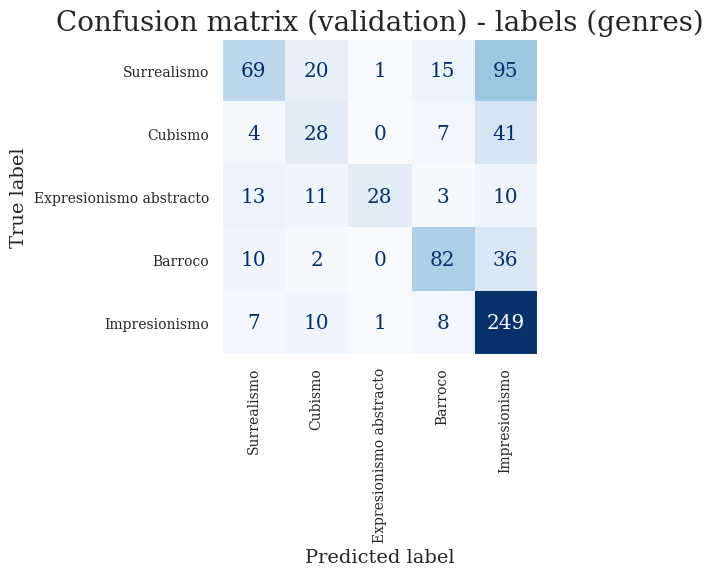

In [37]:
# === Cell 16: confusion matrix for labels (val) ===

cm_label = confusion_matrix(y_l_true, y_l_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_label, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", xticks_rotation=90, ax=ax, colorbar=False)
plt.title("Confusion matrix (validation) - labels (genres)")
plt.tight_layout()
plt.grid(False)
plt.show()


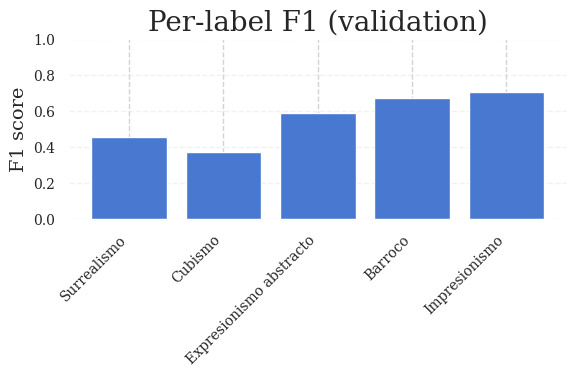

Surrealismo                   : F1 = 0.455
Cubismo                       : F1 = 0.371
Expresionismo abstracto       : F1 = 0.589
Barroco                       : F1 = 0.669
Impresionismo                 : F1 = 0.705


In [38]:
# === Cell 17: per-class F1 for labels ===

f1_per_label = f1_score(
    y_l_true,
    y_l_pred,
    average=None,
    labels=np.arange(NUM_LABELS),
)

plt.figure(figsize=(6, 4))
plt.bar(range(NUM_LABELS), f1_per_label)
plt.xticks(range(NUM_LABELS), class_names, rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.ylabel("F1 score")
plt.title("Per-label F1 (validation)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

for name, f1_val in zip(class_names, f1_per_label):
    print(f"{name:30s}: F1 = {f1_val:.3f}")
